![tracker](https://us-central1-vertex-ai-mlops-369716.cloudfunctions.net/pixel-tracking?path=statmike%2Fvertex-ai-mlops%2FMLOps%2FServing&file=Vertex%20AI%20Endpoint%20-%20Autoscaling.ipynb)
<!--- header table --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://github.com/statmike/vertex-ai-mlops/blob/main/MLOps/Serving/Vertex%20AI%20Endpoint%20-%20Autoscaling.ipynb">
      <img width="32px" src="https://www.svgrepo.com/download/217753/github.svg" alt="GitHub logo">
      <br>View on<br>GitHub
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://colab.research.google.com/github/statmike/vertex-ai-mlops/blob/main/MLOps/Serving/Vertex%20AI%20Endpoint%20-%20Autoscaling.ipynb">
      <img width="32px" src="https://www.gstatic.com/pantheon/images/bigquery/welcome_page/colab-logo.svg" alt="Google Colaboratory logo">
      <br>Run in<br>Colab
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fvertex-ai-mlops%2Fmain%2FMLOps%2FServing%2FVertex%20AI%20Endpoint%20-%20Autoscaling.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Google Cloud Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/workbench/deploy-notebook?download_url=https://raw.githubusercontent.com/statmike/vertex-ai-mlops/main/MLOps/Serving/Vertex%20AI%20Endpoint%20-%20Autoscaling.ipynb">
      <img width="32px" src="https://www.gstatic.com/images/branding/gcpiconscolors/vertexai/v1/32px.svg" alt="Vertex AI logo">
      <br>Open in<br>Vertex AI Workbench
    </a>
  </td>
</tr>
</table>

# Vertex AI Endpoint — Autoscaling Deep Dive

Understand and observe autoscaling behavior on [Vertex AI Endpoints](https://cloud.google.com/vertex-ai/docs/predictions/autoscaling) through load testing and live metric visualization.

**Story arc:**
1. Deploy a model with autoscaling enabled (min=1, max=5 replicas)
2. Explore the Cloud Monitoring metrics that make autoscaling observable
3. Generate load and watch the autoscaler respond — scale up, stabilize, scale down
4. Compare different autoscaling configurations: CPU threshold, request-count metric, custom thresholds
5. Visualize everything with annotated timeline dashboards

**Runtime:** This notebook takes **45–60 minutes** to run because autoscaling events happen on the order of minutes, not seconds. Each experiment section notes its expected duration.

**Prerequisites:** Same HuggingFace sentiment model + custom FastAPI container used across the [Serving notebooks](./readme.md). For prediction method details, see [Vertex AI Endpoint - Prediction Methods](./Vertex%20AI%20Endpoint%20-%20Prediction%20Methods.ipynb).

## How Vertex AI Autoscaling Works

Vertex AI uses a formula-based autoscaler that evaluates every **15 seconds**:

```
target_replicas = Ceil(current_replicas × (current_utilization / target_utilization))
```

The autoscaler uses the **highest target** from a rolling **5-minute lookback window**. This makes it:
- **Aggressive on scale-up** — a single spike triggers scaling
- **Conservative on scale-down** — utilization must stay low for the full 5-minute window

### Default Scaling Metrics

| Metric | Default Target | When Active |
|--------|:-:|---|
| CPU utilization | 60% | Always (CPU-only deployments) |
| GPU duty cycle | 60% | When `accelerator_count > 0` |

With GPUs, the autoscaler monitors **both** CPU and GPU: scales up when **either** exceeds its target, scales down only when **both** are below.

### Optional Scaling Metrics

| Metric | Unit | Use Case |
|--------|------|----------|
| Request count | requests/min/replica | Traffic-based scaling (I/O-bound models) |
| DCGM GPU utilization | % per replica | Fine-grained GPU monitoring (Preview) |
| vLLM KV cache usage | % per replica | LLM-specific scaling (Preview) |
| vLLM requests waiting | count per replica | LLM queue depth (Preview) |
| Pub/Sub messages | count per replica | Event-driven scaling (Preview) |

### Key Timing

| Event | Typical Duration |
|-------|:---:|
| Autoscaler evaluation cycle | Every 15 seconds |
| Scale-up decision (after threshold exceeded) | 15–60 seconds |
| New replica provisioning | 30–120 seconds (CPU) |
| Scale-down stabilization window | 5 minutes (not configurable) |
| Metric propagation to Cloud Monitoring | 60–120 seconds |

> **Note:** Vertex AI reserves ~1 vCPU per replica for system processes. A 2-vCPU machine effectively has 1 vCPU for your model. A single-threaded model on a multi-core machine may never trigger CPU-based scaling.

---
## Colab Setup

To run this notebook in Colab run the cells in this section. Otherwise, skip this section.

This cell will authenticate to GCP (follow prompts in the popup).

In [1]:
PROJECT_ID = 'statmike-mlops-349915' # replace with your project ID

In [2]:
try:
    import google.colab
    from google.colab import auth
    auth.authenticate_user()
    !gcloud config set project {PROJECT_ID}
except Exception:
    pass

---
## Environment

> **Already set up the project environment?** The cell below is a no-op — packages are already in your kernel. See the [README](readme.md) for uv setup details.
>
> **Running standalone** (Colab, Colab Enterprise, Vertex AI Workbench)? The cell below installs required packages into your current kernel.

In [3]:
import subprocess, sys, shutil

def install(*packages):
    uv = shutil.which('uv')
    if uv:
        subprocess.check_call([uv, 'pip', 'install', '-q', '--python', sys.executable, *packages])
    else:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', *packages])

install(
    'google-cloud-aiplatform', 'google-cloud-storage',
    'google-cloud-artifact-registry', 'google-cloud-build',
    'google-cloud-monitoring',
    'transformers', 'torch', 'sentencepiece',
    'httpx', 'aiohttp', 'matplotlib',
)

### API Enablement

In [4]:
!gcloud services enable aiplatform.googleapis.com
!gcloud services enable artifactregistry.googleapis.com
!gcloud services enable cloudbuild.googleapis.com
!gcloud services enable monitoring.googleapis.com

---
## Setup

inputs:

In [5]:
project = !gcloud config get-value project
PROJECT_ID = project[-1]
PROJECT_ID

'statmike-mlops-349915'

In [6]:
REGION = 'us-central1'
SERIES = 'mlops'
EXPERIMENT = 'autoscaling'

GCS_BUCKET = PROJECT_ID
AR_REPO = 'mlops-serving'  # Artifact Registry Docker repo

In [7]:
project_number = !gcloud projects describe {PROJECT_ID} --format='value(projectNumber)'
PROJECT_NUMBER = project_number[0]
PROJECT_NUMBER

'1026793852137'

packages:

In [8]:
import json, os, time, tempfile, subprocess, asyncio
from datetime import datetime, timedelta, timezone

from transformers import AutoModelForSequenceClassification, AutoTokenizer

import google.auth
import google.auth.transport.requests
from google.cloud import storage
from google.cloud import artifactregistry_v1
from google.cloud.devtools import cloudbuild_v1
from google.cloud import aiplatform
from google.cloud import monitoring_v3

import requests as req_lib
import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from google.api import metric_pb2

/home/user/git/vertex-ai-mlops/MLOps/Serving/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


clients:

In [9]:
gcs = storage.Client(project = PROJECT_ID)
bucket = gcs.bucket(GCS_BUCKET)

cb = cloudbuild_v1.CloudBuildClient()

ar = artifactregistry_v1.ArtifactRegistryClient()

aiplatform.init(project = PROJECT_ID, location = REGION)

monitoring_client = monitoring_v3.MetricServiceClient()

Parameters:

In [10]:
DIR = f"files/{EXPERIMENT}"
if not os.path.exists(DIR + '/source/app'):
    os.makedirs(DIR + '/source/app')

---
## Download HuggingFace Model

Same DistilBERT sentiment model used across all Serving notebooks. One model — the focus here is autoscaling behavior, not model variety.

In [11]:
MODEL = {
    'hub_name': 'distilbert-base-uncased-finetuned-sst-2-english',
    'display_name': 'distilbert-sst2',
}

In [12]:
gcs_prefix = f'{SERIES}/{EXPERIMENT}/models/v1'

# check if already uploaded
existing = list(bucket.list_blobs(prefix=gcs_prefix, max_results=1))
if existing:
    print(f'Model already in GCS at gs://{GCS_BUCKET}/{gcs_prefix}')
else:
    print(f'Downloading {MODEL["hub_name"]} ...')
    with tempfile.TemporaryDirectory() as tmpdir:
        model = AutoModelForSequenceClassification.from_pretrained(MODEL['hub_name'])
        tokenizer = AutoTokenizer.from_pretrained(MODEL['hub_name'])
        model.save_pretrained(tmpdir)
        tokenizer.save_pretrained(tmpdir)
        
        for root, dirs, files in os.walk(tmpdir):
            for fname in files:
                local_path = os.path.join(root, fname)
                blob_name = f'{gcs_prefix}/{os.path.relpath(local_path, tmpdir)}'
                bucket.blob(blob_name).upload_from_filename(local_path)
        print(f'  Uploaded to gs://{GCS_BUCKET}/{gcs_prefix}')

MODEL['artifact_uri'] = f'gs://{GCS_BUCKET}/{gcs_prefix}'

Model already in GCS at gs://statmike-mlops-349915/mlops/autoscaling/models/v1


---
## Build Custom Prediction Container

Same FastAPI container used across the Serving notebooks.

### Setup Artifact Registry

In [13]:
docker_repo = None
for repo in ar.list_repositories(parent=f'projects/{PROJECT_ID}/locations/{REGION}'):
    if AR_REPO == repo.name.split('/')[-1]:
        docker_repo = repo
        print(f'Retrieved existing repo: {docker_repo.name}')

if not docker_repo:
    operation = ar.create_repository(
        request=artifactregistry_v1.CreateRepositoryRequest(
            parent=f'projects/{PROJECT_ID}/locations/{REGION}',
            repository_id=AR_REPO,
            repository=artifactregistry_v1.Repository(
                description=f'Docker images for the {SERIES} series.',
                name=AR_REPO,
                format_=artifactregistry_v1.Repository.Format.DOCKER,
                labels={'series': SERIES},
            ),
        )
    )
    print('Creating Repository ...')
    docker_repo = operation.result()
    print(f'Completed creating repo: {docker_repo.name}')

Retrieved existing repo: projects/statmike-mlops-349915/locations/us-central1/repositories/mlops-serving


In [14]:
REPOSITORY = f"{REGION}-docker.pkg.dev/{PROJECT_ID}/{docker_repo.name.split('/')[-1]}"
REPOSITORY

'us-central1-docker.pkg.dev/statmike-mlops-349915/mlops-serving'

### Create Application Files

In [15]:
%%writefile {DIR}/source/Dockerfile
FROM tiangolo/uvicorn-gunicorn-fastapi:python3.10

COPY ./app /app
COPY ./requirements.txt requirements.txt

RUN pip install --no-cache-dir --upgrade pip \
  && pip install --no-cache-dir -r requirements.txt

Overwriting files/autoscaling/source/Dockerfile


In [16]:
%%writefile {DIR}/source/requirements.txt
google-cloud-storage
transformers
torch
sentencepiece

Overwriting files/autoscaling/source/requirements.txt


In [17]:
%%writefile {DIR}/source/app/__init__.py
# init file

Overwriting files/autoscaling/source/app/__init__.py


In [18]:
%%writefile {DIR}/source/app/main.py
import os
from fastapi import FastAPI, Request
from transformers import pipeline
from google.cloud import storage

app = FastAPI()

# Download model files from GCS (set by AIP_STORAGE_URI)
gcs = storage.Client()
storage_uri = os.environ['AIP_STORAGE_URI']
parts = storage_uri.replace('gs://', '').split('/', 1)
bucket = gcs.bucket(parts[0])
prefix = parts[1] if len(parts) > 1 else ''

model_dir = '/tmp/model'
os.makedirs(model_dir, exist_ok=True)
for blob in bucket.list_blobs(prefix=prefix):
    rel = blob.name[len(prefix):].lstrip('/')
    if rel:
        local = os.path.join(model_dir, rel)
        os.makedirs(os.path.dirname(local), exist_ok=True)
        blob.download_to_filename(local)

# Load the sentiment analysis pipeline
classifier = pipeline('sentiment-analysis', model=model_dir, tokenizer=model_dir)


@app.get(os.environ['AIP_HEALTH_ROUTE'], status_code=200)
def health():
    return {}


@app.post(os.environ['AIP_PREDICT_ROUTE'])
async def predict(request: Request):
    body = await request.json()
    instances = body['instances']
    results = classifier(instances)
    return {
        'predictions': [
            {'label': r['label'], 'score': round(r['score'], 6)}
            for r in results
        ]
    }

Overwriting files/autoscaling/source/app/main.py


In [19]:
%%writefile {DIR}/source/app/prestart.sh
#!/bin/bash
export PORT=$AIP_HTTP_PORT

Overwriting files/autoscaling/source/app/prestart.sh


### Upload Source to GCS

In [20]:
source_files = [
    'Dockerfile',
    'requirements.txt',
    'app/__init__.py',
    'app/main.py',
    'app/prestart.sh',
]
for f in source_files:
    bucket.blob(f'{SERIES}/{EXPERIMENT}/source/{f}').upload_from_filename(f'{DIR}/source/{f}')

print('Source files uploaded to GCS:')
for blob in bucket.list_blobs(prefix=f'{SERIES}/{EXPERIMENT}/source'):
    print(f'  gs://{bucket.name}/{blob.name}')

Source files uploaded to GCS:
  gs://statmike-mlops-349915/mlops/autoscaling/source/Dockerfile
  gs://statmike-mlops-349915/mlops/autoscaling/source/app/__init__.py
  gs://statmike-mlops-349915/mlops/autoscaling/source/app/main.py
  gs://statmike-mlops-349915/mlops/autoscaling/source/app/prestart.sh
  gs://statmike-mlops-349915/mlops/autoscaling/source/requirements.txt


### Build Container with Cloud Build

In [21]:
IMAGE_URI = f'{REPOSITORY}/{EXPERIMENT}'

# Check if image already exists in Artifact Registry
existing_images = list(ar.list_docker_images(
    parent=f'projects/{PROJECT_ID}/locations/{REGION}/repositories/{AR_REPO}',
))
image_exists = any(IMAGE_URI in img.uri for img in existing_images)

if image_exists:
    print(f'Image already exists: {IMAGE_URI}')
else:
    build = cloudbuild_v1.Build(steps=[])

    # Step 1: retrieve source from GCS
    build.steps.append({
        'name': 'gcr.io/cloud-builders/gsutil',
        'args': ['cp', '-r', f'gs://{GCS_BUCKET}/{SERIES}/{EXPERIMENT}/source/*', '/workspace'],
    })

    # Step 2: docker build
    build.steps.append({
        'name': 'gcr.io/cloud-builders/docker',
        'args': ['build', '-t', IMAGE_URI, '/workspace'],
    })

    # Push the image
    build.images = [IMAGE_URI]

    print('Starting Cloud Build ...')
    operation = cb.create_build(project_id=PROJECT_ID, build=build)
    build_response = operation.result()
    print(f'Build status: {build_response.status.name}')
    print(f'Image: {IMAGE_URI}')

Image already exists: us-central1-docker.pkg.dev/statmike-mlops-349915/mlops-serving/autoscaling



---
## Upload Model to Vertex AI Model Registry

In [22]:
# Check for existing model in registry
vertex_model = None
for model in aiplatform.Model.list(filter=f'display_name="{EXPERIMENT}-distilbert"'):
    vertex_model = model
    print(f'Retrieved existing model: {vertex_model.resource_name}')
    break

if not vertex_model:
    vertex_model = aiplatform.Model.upload(
        display_name=f'{EXPERIMENT}-distilbert',
        serving_container_image_uri=IMAGE_URI,
        artifact_uri=MODEL['artifact_uri'],
        labels={'series': SERIES, 'experiment': EXPERIMENT, 'version': 'v1'},
    )
    print(f'Uploaded model: {vertex_model.resource_name}')

Retrieved existing model: projects/1026793852137/locations/us-central1/models/2259468907288985600


---
## Create Endpoint and Deploy with Autoscaling

We deploy with **`min_replica_count=1`** and **`max_replica_count=5`** so the autoscaler has room to add replicas under load. The default CPU utilization target is 60%.

We use a dedicated public endpoint for consistency with the other Serving notebooks and to access the dedicated DNS for direct HTTP predictions.

In [23]:
# Check for existing dedicated endpoint
endpoint = None
for ep in aiplatform.Endpoint.list(filter=f'display_name="{EXPERIMENT}"'):
    if ep.dedicated_endpoint_enabled:
        endpoint = ep
        print(f'Retrieved existing endpoint: {endpoint.resource_name}')
        break

if not endpoint:
    endpoint = aiplatform.Endpoint.create(
        display_name=f'{EXPERIMENT}',
        dedicated_endpoint_enabled=True,
        labels={'series': SERIES, 'experiment': EXPERIMENT},
    )
    print(f'Created endpoint: {endpoint.resource_name}')

Retrieved existing endpoint: projects/1026793852137/locations/us-central1/endpoints/2082123729042669568


In [24]:
# Check if model already deployed (retry — dedicated endpoints may need a moment)
already_deployed = False
for attempt in range(3):
    try:
        deployed_models = endpoint.list_models()
        already_deployed = any(dm.display_name == 'distilbert-sst2' for dm in deployed_models)
        break
    except Exception as e:
        if attempt < 2:
            print(f'Endpoint not ready yet ({e.__class__.__name__}), retrying in 30s...')
            time.sleep(30)
        else:
            print(f'Endpoint query failed after retries, assuming no models deployed')

if already_deployed:
    print(f'Model already deployed on endpoint')
    print(f'Traffic split: {endpoint.traffic_split}')
else:
    endpoint.deploy(
        model=vertex_model,
        deployed_model_display_name='distilbert-sst2',
        machine_type='n1-standard-4',
        min_replica_count=1,
        max_replica_count=5,
        autoscaling_target_cpu_utilization=60,
        traffic_percentage=100,
    )
    print(f'Deployed with autoscaling: min=1, max=5, CPU target=60%')

Model already deployed on endpoint
Traffic split: {'240688043122491392': 100}


In [25]:
# Get the deployed model ID — needed for mutateDeployedModel later
deployed_model = endpoint.list_models()[0]
DEPLOYED_MODEL_ID = deployed_model.id
ENDPOINT_ID = endpoint.name.split('/')[-1]

print(f'Endpoint:          {endpoint.resource_name}')
print(f'Dedicated DNS:     {endpoint.dedicated_endpoint_dns}')
print(f'Deployed model ID: {DEPLOYED_MODEL_ID}')

Endpoint:          projects/1026793852137/locations/us-central1/endpoints/2082123729042669568
Dedicated DNS:     2082123729042669568.us-central1-1026793852137.prediction.vertexai.goog
Deployed model ID: 240688043122491392


### Verify Endpoint

In [26]:
TEST_INSTANCES = [
    "This movie is absolutely wonderful and I loved every minute of it!",
    "The food was terrible and the service was even worse.",
    "An average experience, nothing special but not bad either.",
]

response = endpoint.predict(instances=TEST_INSTANCES)
for instance, pred in zip(TEST_INSTANCES, response.predictions):
    print(f'  "{instance[:50]}..." => {pred["label"]} ({pred["score"]})')

  "This movie is absolutely wonderful and I loved eve..." => POSITIVE (0.999887)
  "The food was terrible and the service was even wor..." => NEGATIVE (0.999793)
  "An average experience, nothing special but not bad..." => POSITIVE (0.859379)


In [27]:
# Credentials and URL for direct HTTP predictions
credentials, _ = google.auth.default()
auth_req = google.auth.transport.requests.Request()
credentials.refresh(auth_req)

PREDICT_URL = f'https://{endpoint.dedicated_endpoint_dns}/v1/{endpoint.resource_name}:predict'
print(f'Predict URL: {PREDICT_URL}')

Predict URL: https://2082123729042669568.us-central1-1026793852137.prediction.vertexai.goog/v1/projects/1026793852137/locations/us-central1/endpoints/2082123729042669568:predict


---
## Exploring Cloud Monitoring Metrics

Vertex AI Endpoints emit metrics to [Cloud Monitoring](https://cloud.google.com/vertex-ai/docs/general/monitoring-metrics) under `aiplatform.googleapis.com/prediction/online/`. These metrics are how we observe autoscaling decisions, resource utilization, and request performance.

Let's discover what's available and build a reusable query helper.

### Discover Available Metrics

In [28]:
# List all prediction metrics available for Vertex AI Endpoints
project_name = f'projects/{PROJECT_ID}'

print(f'{"Metric":70s} {"Kind":12s} {"Value Type"}')
print('-' * 100)
for descriptor in monitoring_client.list_metric_descriptors(
    request={
        'name': project_name,
        'filter': 'metric.type = starts_with("aiplatform.googleapis.com/prediction/online")',
    }
):
    kind = metric_pb2.MetricDescriptor.MetricKind.Name(descriptor.metric_kind)
    vtype = metric_pb2.MetricDescriptor.ValueType.Name(descriptor.value_type)
    print(f'{descriptor.type:70s} {kind:12s} {vtype}')

Metric                                                                 Kind         Value Type
----------------------------------------------------------------------------------------------------
aiplatform.googleapis.com/prediction/online/accelerator/duty_cycle     GAUGE        DOUBLE
aiplatform.googleapis.com/prediction/online/accelerator/memory/bytes_used GAUGE        INT64
aiplatform.googleapis.com/prediction/online/cpu/utilization            GAUGE        DOUBLE
aiplatform.googleapis.com/prediction/online/deployment_resource_pool/accelerator/duty_cycle GAUGE        DOUBLE
aiplatform.googleapis.com/prediction/online/deployment_resource_pool/accelerator/memory/bytes_used GAUGE        INT64
aiplatform.googleapis.com/prediction/online/deployment_resource_pool/cpu/utilization GAUGE        DOUBLE
aiplatform.googleapis.com/prediction/online/deployment_resource_pool/memory/bytes_used GAUGE        INT64
aiplatform.googleapis.com/prediction/online/deployment_resource_pool/network/received_by

### Key Metrics for Autoscaling

| Metric | Kind | What It Shows | Best Aligner |
|--------|------|---------------|:---:|
| `prediction/online/replicas` | GAUGE | Current replica count | `ALIGN_MAX` |
| `prediction/online/target_replicas` | GAUGE | Autoscaler's desired count | `ALIGN_MAX` |
| `prediction/online/cpu/utilization` | GAUGE | CPU fraction per replica (0.0–1.0+) | `ALIGN_MEAN` |
| `prediction/online/memory/bytes_used` | GAUGE | Memory per replica | `ALIGN_MEAN` |
| `prediction/online/prediction_count` | DELTA | Inference count | `ALIGN_RATE` |
| `prediction/online/response_count` | DELTA | HTTP response count | `ALIGN_RATE` |
| `prediction/online/prediction_latencies` | DISTRIBUTION | End-to-end latency | `ALIGN_PERCENTILE_95` |
| `prediction/online/error_count` | DELTA | Error count | `ALIGN_RATE` |

The **gold metric pair** is `replicas` vs `target_replicas` — comparing them shows the autoscaler's *intent* versus *reality*. When target > actual, the system is actively provisioning. When target < actual, it's cooling down.

> **Sparse metric gotcha:** CPU, memory, and latency metrics are "sparse" — they only report data points when there is activity. If you aggregate sparse metrics with `ALIGN_MEAN`, time buckets with no data get averaged to zero, which misrepresents the actual state. The query helper below handles this by querying raw data and resampling with forward-fill.

### Build Metric Query Helper

In [29]:
def query_metric(metric_type, endpoint_id, start_time, end_time,
                 resolution_seconds=60, aligner='ALIGN_MEAN'):
    """
    Query a Cloud Monitoring metric for a Vertex AI Endpoint.
    
    Handles sparse metrics (CPU, memory, latency) by querying raw data
    and resampling with forward-fill to avoid zero-averaging.
    
    Returns a pandas DataFrame with 'timestamp' and 'value' columns.
    """
    interval = monitoring_v3.TimeInterval({
        'start_time': {'seconds': int(start_time.timestamp())},
        'end_time':   {'seconds': int(end_time.timestamp())},
    })
    
    metric_filter = (
        f'resource.type="aiplatform.googleapis.com/Endpoint"'
        f' AND resource.labels.endpoint_id="{endpoint_id}"'
        f' AND metric.type="{metric_type}"'
    )
    
    # Sparse metrics: query raw, resample in pandas
    sparse_metrics = [
        'aiplatform.googleapis.com/prediction/online/cpu/utilization',
        'aiplatform.googleapis.com/prediction/online/memory/bytes_used',
        'aiplatform.googleapis.com/prediction/online/prediction_latencies',
    ]
    
    if metric_type in sparse_metrics:
        request = monitoring_v3.ListTimeSeriesRequest({
            'name': f'projects/{PROJECT_ID}',
            'filter': metric_filter,
            'interval': interval,
            'view': monitoring_v3.ListTimeSeriesRequest.TimeSeriesView.FULL,
        })
    else:
        aggregation = monitoring_v3.Aggregation({
            'alignment_period': {'seconds': resolution_seconds},
            'per_series_aligner': getattr(monitoring_v3.Aggregation.Aligner, aligner),
        })
        request = monitoring_v3.ListTimeSeriesRequest({
            'name': f'projects/{PROJECT_ID}',
            'filter': metric_filter,
            'interval': interval,
            'aggregation': aggregation,
            'view': monitoring_v3.ListTimeSeriesRequest.TimeSeriesView.FULL,
        })
    
    rows = []
    try:
        for ts in monitoring_client.list_time_series(request=request):
            for point in ts.points:
                val = point.value
                if hasattr(val, 'distribution_value') and val.distribution_value.count > 0:
                    value = val.distribution_value.mean
                elif val.int64_value != 0:
                    value = float(val.int64_value)
                elif val.double_value != 0.0:
                    value = val.double_value
                else:
                    value = 0.0
                rows.append({
                    'timestamp': pd.Timestamp(point.interval.end_time),
                    'value': value,
                })
    except Exception as e:
        print(f'Warning: Could not fetch {metric_type.split("/")[-1]}: {str(e)[:200]}')
    
    if not rows:
        return pd.DataFrame(columns=['timestamp', 'value'])
    
    df = pd.DataFrame(rows).sort_values('timestamp')
    
    # Resample sparse metrics with forward-fill
    if metric_type in sparse_metrics and len(df) > 0:
        df = df.set_index('timestamp')
        df = df.resample(f'{resolution_seconds}s').mean().ffill().reset_index()
    
    return df

print('query_metric() helper defined')

query_metric() helper defined


### Collect All Metrics

In [30]:
def collect_all_metrics(endpoint_id, start_time, end_time, resolution_seconds=60):
    """
    Collect all autoscaling-relevant metrics for a time window.
    Adds a 2-minute buffer on each side for metric propagation lag.
    """
    buffered_start = start_time - timedelta(minutes=2)
    buffered_end = end_time + timedelta(minutes=2)
    
    metrics = {}
    metric_configs = [
        ('replicas',    'aiplatform.googleapis.com/prediction/online/replicas',           'ALIGN_MAX'),
        ('target',      'aiplatform.googleapis.com/prediction/online/target_replicas',    'ALIGN_MAX'),
        ('cpu',         'aiplatform.googleapis.com/prediction/online/cpu/utilization',    'ALIGN_MEAN'),
        ('predictions', 'aiplatform.googleapis.com/prediction/online/prediction_count',   'ALIGN_RATE'),
        ('latency',     'aiplatform.googleapis.com/prediction/online/prediction_latencies','ALIGN_PERCENTILE_95'),
        ('errors',      'aiplatform.googleapis.com/prediction/online/error_count',        'ALIGN_RATE'),
    ]
    
    for name, metric_type, aligner in metric_configs:
        print(f'  Collecting {name}...')
        metrics[name] = query_metric(
            metric_type, endpoint_id,
            buffered_start, buffered_end,
            resolution_seconds, aligner,
        )
    
    print(f'Collected {sum(len(df) for df in metrics.values())} total data points')
    return metrics

print('collect_all_metrics() helper defined')

collect_all_metrics() helper defined


### Query Baseline (Idle) Metrics

Let's see what the endpoint looks like at rest — 1 replica, low CPU, no traffic.

In [31]:
# Query the last 10 minutes to see the idle baseline
now = datetime.now(timezone.utc)
baseline_metrics = collect_all_metrics(
    ENDPOINT_ID,
    start_time=now - timedelta(minutes=10),
    end_time=now,
)

for name, df in baseline_metrics.items():
    if len(df) > 0:
        print(f'  {name:12s}: {len(df):3d} points, latest value = {df["value"].iloc[-1]:.4f}')
    else:
        print(f'  {name:12s}: no data (normal for idle endpoint)')

Collected 42 total data points
  replicas    :  11 points, latest value = 4.0000
  target      :  11 points, latest value = 4.0000
  cpu         :   7 points, latest value = 0.0027
  predictions :   7 points, latest value = 6.3934
  latency     :   6 points, latest value = 0.0000
  errors      : no data (normal for idle endpoint)


---
## Build Visualization Dashboard

A reusable 4-panel matplotlib figure that shows the complete autoscaling story: replicas, CPU, throughput, and latency on aligned time axes.

In [32]:
def plot_autoscaling_dashboard(metrics, title='Autoscaling Dashboard',
                               events=None, cpu_threshold=60):
    """
    4-panel autoscaling dashboard with aligned time axes.
    
    Args:
        metrics: dict of DataFrames from collect_all_metrics()
        title: chart title
        events: dict of {'label': datetime} for vertical markers
        cpu_threshold: horizontal line on CPU panel (default 60%)
    """
    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    colors = {
        'replicas': '#2E86AB',
        'target':   '#2E86AB',
        'cpu':      '#E8384F',
        'requests': '#34A853',
        'latency':  '#7B61FF',
    }
    
    # Panel 1: Replica count (actual vs target)
    ax = axes[0]
    if 'replicas' in metrics and len(metrics['replicas']) > 0:
        ax.step(metrics['replicas']['timestamp'], metrics['replicas']['value'],
                where='post', color=colors['replicas'], linewidth=2, label='Actual')
    if 'target' in metrics and len(metrics['target']) > 0:
        ax.step(metrics['target']['timestamp'], metrics['target']['value'],
                where='post', color=colors['target'], linewidth=1.5,
                linestyle='--', alpha=0.6, label='Target')
    ax.set_ylabel('Replicas')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(loc='upper left', fontsize=8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    # Panel 2: CPU utilization
    ax = axes[1]
    if 'cpu' in metrics and len(metrics['cpu']) > 0:
        cpu_pct = metrics['cpu']['value'] * 100
        ax.fill_between(metrics['cpu']['timestamp'], cpu_pct, alpha=0.3, color=colors['cpu'])
        ax.plot(metrics['cpu']['timestamp'], cpu_pct, color=colors['cpu'], linewidth=1.5)
    if cpu_threshold is not None:
        ax.axhline(y=cpu_threshold, color='orange', linestyle='--', alpha=0.7,
                  label=f'Threshold ({cpu_threshold}%)')
        ax.legend(loc='upper left', fontsize=8)
    ax.set_ylabel('CPU %')
    ax.set_ylim(bottom=0)
    
    # Panel 3: Request throughput
    ax = axes[2]
    if 'predictions' in metrics and len(metrics['predictions']) > 0:
        ax.fill_between(metrics['predictions']['timestamp'],
                        metrics['predictions']['value'],
                        alpha=0.2, color=colors['requests'])
        ax.plot(metrics['predictions']['timestamp'], metrics['predictions']['value'],
                color=colors['requests'], linewidth=1.5)
    ax.set_ylabel('Predictions/sec')
    ax.set_ylim(bottom=0)
    
    # Panel 4: P95 latency
    ax = axes[3]
    if 'latency' in metrics and len(metrics['latency']) > 0:
        ax.fill_between(metrics['latency']['timestamp'],
                        metrics['latency']['value'],
                        alpha=0.2, color=colors['latency'])
        ax.plot(metrics['latency']['timestamp'], metrics['latency']['value'],
                color=colors['latency'], linewidth=1.5)
    ax.set_ylabel('P95 Latency (ms)')
    ax.set_xlabel('Time (UTC)')
    ax.set_ylim(bottom=0)
    
    # Add vertical event markers
    if events:
        event_colors = ['green', 'red', 'purple', 'orange']
        for i, (label, event_time) in enumerate(events.items()):
            color = event_colors[i % len(event_colors)]
            for ax in axes:
                ax.axvline(x=event_time, color=color, linestyle='-', alpha=0.5, linewidth=2)
            axes[0].text(event_time, axes[0].get_ylim()[1] * 0.95, f' {label}',
                        fontsize=8, color=color, va='top')
    
    # Format x-axis
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    fig.autofmt_xdate(rotation=45)
    fig.tight_layout()
    plt.show()
    plt.close(fig)

print('plot_autoscaling_dashboard() defined')

plot_autoscaling_dashboard() defined


---
## Experiment 1: CPU-Triggered Scale-Up and Scale-Down

The default autoscaling trigger is **CPU utilization > 60%**. We generate sustained load to push CPU above the threshold, watch the autoscaler add replicas, then stop the load and watch it scale back down.

**Expected duration:** ~25 minutes (10 min load + 2 min metric wait + 12 min scale-down observation)

### Load Generator

In [33]:
async def generate_load(predict_url, credentials, auth_req,
                        instances, target_rps=20, duration_seconds=600,
                        max_concurrent=50):
    """
    Generate sustained load at a target RPS for a fixed duration.
    Returns (start_time, end_time, results_df).
    """
    credentials.refresh(auth_req)
    headers = {
        'Authorization': f'Bearer {credentials.token}',
        'Content-Type': 'application/json',
    }
    payload = json.dumps({'instances': instances})
    semaphore = asyncio.Semaphore(max_concurrent)
    results = []
    
    async def send_request(client, request_id):
        async with semaphore:
            start = time.perf_counter()
            try:
                resp = await client.post(
                    predict_url,
                    content=payload,
                    headers=headers,
                    timeout=30.0,
                )
                elapsed = (time.perf_counter() - start) * 1000
                return {'id': request_id, 'status': resp.status_code, 'latency_ms': elapsed}
            except Exception as e:
                elapsed = (time.perf_counter() - start) * 1000
                return {'id': request_id, 'status': 0, 'latency_ms': elapsed, 'error': str(e)[:100]}
    
    interval = 1.0 / target_rps
    total_requests = target_rps * duration_seconds
    
    print(f'Generating load: {target_rps} RPS for {duration_seconds}s ({total_requests:,} requests)')
    print(f'Progress updates every 60 seconds...')
    
    start_time = datetime.now(timezone.utc)
    test_start = time.perf_counter()
    last_progress = 0
    
    async with httpx.AsyncClient() as client:
        tasks = []
        for i in range(total_requests):
            target_time = test_start + (i * interval)
            wait = target_time - time.perf_counter()
            if wait > 0:
                await asyncio.sleep(wait)
            
            # Refresh credentials every 30 minutes
            if i > 0 and i % (target_rps * 1800) == 0:
                credentials.refresh(auth_req)
                headers['Authorization'] = f'Bearer {credentials.token}'
            
            tasks.append(asyncio.create_task(send_request(client, i)))
            
            elapsed_time = time.perf_counter() - test_start
            if int(elapsed_time) >= last_progress + 60:
                last_progress = int(elapsed_time)
                completed = sum(1 for t in tasks if t.done())
                print(f'  [{last_progress:>4d}s] {i+1:,} sent, {completed:,} completed')
        
        print(f'  Waiting for remaining requests...')
        results = await asyncio.gather(*tasks)
    
    end_time = datetime.now(timezone.utc)
    df = pd.DataFrame(results)
    success = df[df['status'] == 200]
    print(f'Done: {len(success):,}/{len(df):,} succeeded '
          f'({len(success)/len(df)*100:.1f}%), '
          f'mean latency {success["latency_ms"].mean():.0f}ms')
    
    return start_time, end_time, df

print('generate_load() defined')

generate_load() defined


### Run Sustained Load

In [34]:
# Generate sustained load to trigger CPU-based autoscaling
# 20 RPS with 3 instances per request = 60 inferences/sec on our small model
load_start, load_end, load_results = await generate_load(
    PREDICT_URL, credentials, auth_req,
    instances=TEST_INSTANCES,
    target_rps=20,
    duration_seconds=600,  # 10 minutes
    max_concurrent=50,
)

Generating load: 20 RPS for 600s (12,000 requests)
Progress updates every 60 seconds...
  [  60s] 1,201 sent, 552 completed
  [ 120s] 2,401 sent, 1,337 completed
  [ 180s] 3,601 sent, 2,224 completed
  [ 240s] 4,801 sent, 3,550 completed
  [ 300s] 6,001 sent, 5,132 completed
  [ 360s] 7,201 sent, 7,199 completed
  [ 420s] 8,401 sent, 8,398 completed
  [ 480s] 9,601 sent, 9,598 completed
  [ 540s] 10,801 sent, 10,798 completed
  Waiting for remaining requests...
Done: 11,895/12,000 succeeded (99.1%), mean latency 1536ms


### Wait for Metrics

Cloud Monitoring metrics have a **60–120 second propagation delay**. We wait 90 seconds before querying to ensure the data is available.

In [35]:
print('Waiting 90 seconds for metrics to propagate...')
for remaining in range(90, 0, -30):
    print(f'  {remaining}s remaining...')
    time.sleep(30)
print('Ready to collect metrics.')

Waiting 90 seconds for metrics to propagate...
  90s remaining...
  60s remaining...
  30s remaining...
Ready to collect metrics.


### Collect and Visualize Scale-Up

Collected 82 total data points


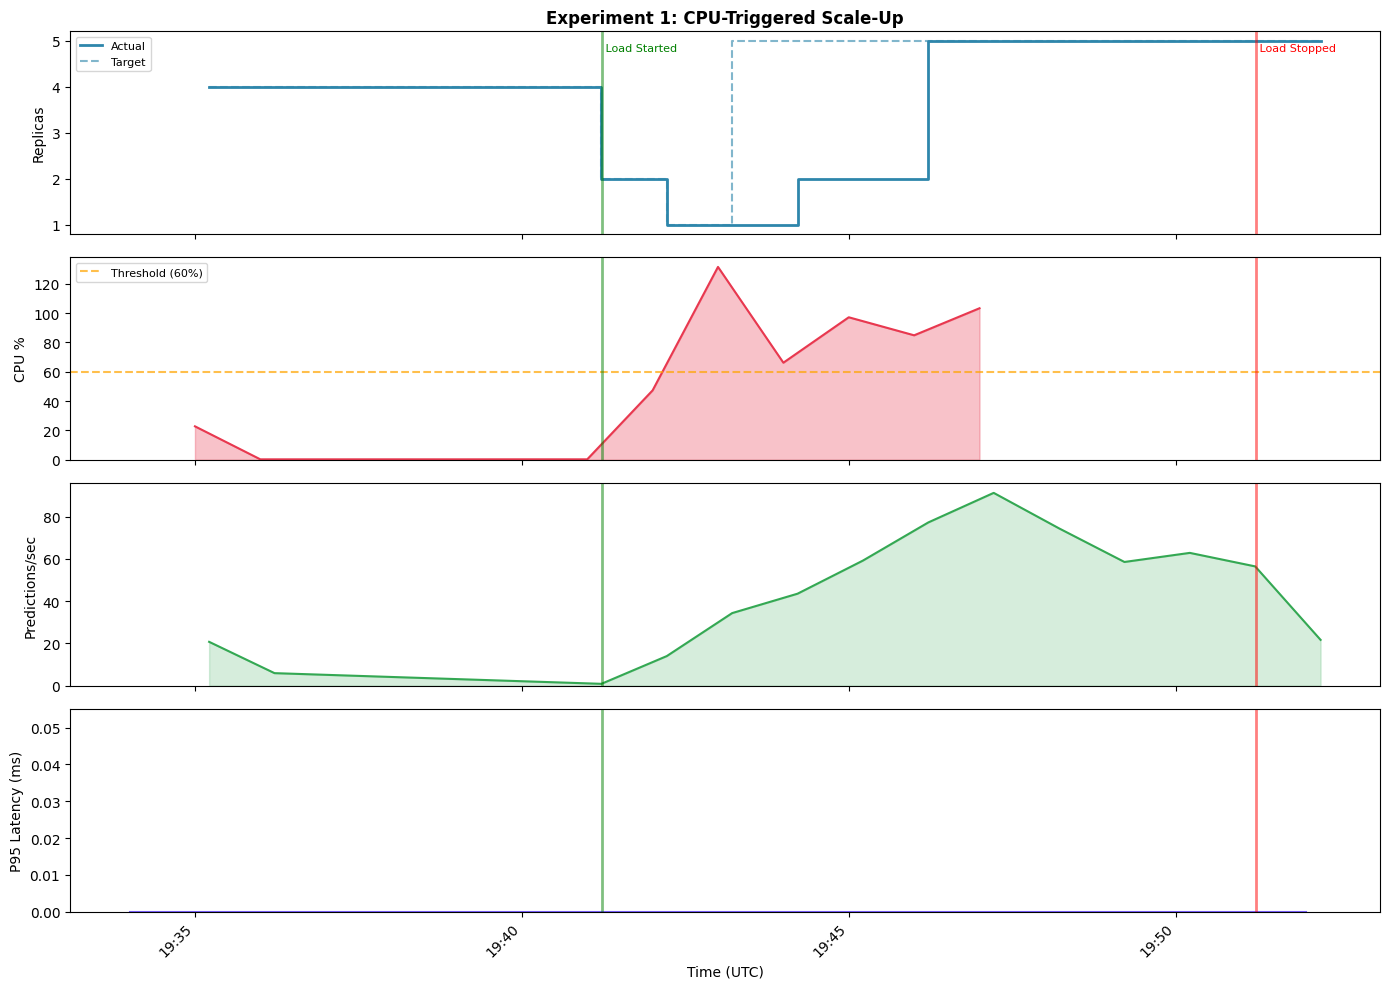

In [36]:
# Collect metrics covering the load period
print('Collecting metrics for load period...')
load_metrics = collect_all_metrics(
    ENDPOINT_ID,
    start_time=load_start - timedelta(minutes=5),  # include pre-load baseline
    end_time=load_end + timedelta(minutes=2),
)

plot_autoscaling_dashboard(
    load_metrics,
    title='Experiment 1: CPU-Triggered Scale-Up',
    events={'Load Started': load_start, 'Load Stopped': load_end},
)

### Analyze Scale-Up Timing

In [37]:
def analyze_scaling_events(metrics, load_start, load_end):
    """
    Detect scale-up and scale-down events from replica metrics.
    Returns a summary dict with timing information.
    """
    results = {'events': []}
    
    if 'replicas' not in metrics or len(metrics['replicas']) == 0:
        print('No replica data available')
        return results
    
    replica_df = metrics['replicas'].copy()
    replica_df['change'] = replica_df['value'].diff()
    
    # Scale-up events
    scale_ups = replica_df[replica_df['change'] > 0]
    for _, row in scale_ups.iterrows():
        lag = (row['timestamp'] - load_start).total_seconds()
        results['events'].append({
            'type': 'scale-up',
            'time': row['timestamp'],
            'replicas': int(row['value']),
            'lag_from_load_start': lag,
        })
    
    # Scale-down events
    scale_downs = replica_df[replica_df['change'] < 0]
    for _, row in scale_downs.iterrows():
        lag = (row['timestamp'] - load_end).total_seconds()
        results['events'].append({
            'type': 'scale-down',
            'time': row['timestamp'],
            'replicas': int(row['value']),
            'lag_from_load_end': lag,
        })
    
    # CPU at first scale-up
    if scale_ups is not None and len(scale_ups) > 0 and 'cpu' in metrics and len(metrics['cpu']) > 0:
        first_scale = scale_ups.iloc[0]['timestamp']
        cpu_before = metrics['cpu'][metrics['cpu']['timestamp'] <= first_scale]
        if len(cpu_before) > 0:
            results['cpu_at_trigger'] = cpu_before['value'].iloc[-1] * 100
    
    # Target vs actual gap
    if 'target' in metrics and len(metrics['target']) > 0:
        target_ups = metrics['target'].copy()
        target_ups['change'] = target_ups['value'].diff()
        target_increases = target_ups[target_ups['change'] > 0]
        if len(target_increases) > 0 and len(scale_ups) > 0:
            first_target = target_increases.iloc[0]['timestamp']
            first_actual = scale_ups.iloc[0]['timestamp']
            results['decision_to_ready'] = (first_actual - first_target).total_seconds()
    
    return results

scaling_analysis = analyze_scaling_events(load_metrics, load_start, load_end)

print('Scale-Up Analysis:')
print(f'  Load started at: {load_start.strftime("%H:%M:%S")} UTC')
if 'cpu_at_trigger' in scaling_analysis:
    print(f'  CPU at first scale-up: {scaling_analysis["cpu_at_trigger"]:.1f}%')
if 'decision_to_ready' in scaling_analysis:
    print(f'  Decision-to-ready lag: {scaling_analysis["decision_to_ready"]:.0f}s')
print()
for event in scaling_analysis.get('events', []):
    if event['type'] == 'scale-up':
        print(f'  Scale-up to {event["replicas"]} replicas at '
              f'{event["time"].strftime("%H:%M:%S")} '
              f'({event["lag_from_load_start"]:.0f}s after load start)')

Scale-Up Analysis:
  Load started at: 19:41:13 UTC
  CPU at first scale-up: 66.1%
  Decision-to-ready lag: 60s

  Scale-up to 2 replicas at 19:44:13 (179s after load start)
  Scale-up to 5 replicas at 19:46:13 (299s after load start)


### Monitor Scale-Down

After stopping the load, the autoscaler uses a **5-minute stabilization window** — it won't scale down until CPU has been below the threshold for the full window. Then it takes additional time to actually remove the replica.

This is the part most people never see documented. Let's watch it happen.

**Expected wait:** ~10-12 minutes

In [38]:
# Wait for scale-down to happen
# The 5-minute stabilization window starts when load stops,
# plus time for the actual scale-down operation
print('Monitoring for scale-down (this takes ~10-12 minutes)...')
print(f'Load ended at {load_end.strftime("%H:%M:%S")} UTC')
print(f'Stabilization window ends ~{(load_end + timedelta(minutes=5)).strftime("%H:%M:%S")} UTC')
print()

scale_down_wait = 12 * 60  # 12 minutes
for elapsed in range(0, scale_down_wait, 60):
    remaining = scale_down_wait - elapsed
    print(f'  [{elapsed:>3d}s] Waiting... ({remaining // 60}m {remaining % 60}s remaining)')
    time.sleep(60)

print('Scale-down observation period complete.')

Monitoring for scale-down (this takes ~10-12 minutes)...
Load ended at 19:51:13 UTC
Stabilization window ends ~19:56:13 UTC

  [  0s] Waiting... (12m 0s remaining)
  [ 60s] Waiting... (11m 0s remaining)
  [120s] Waiting... (10m 0s remaining)
  [180s] Waiting... (9m 0s remaining)
  [240s] Waiting... (8m 0s remaining)
  [300s] Waiting... (7m 0s remaining)
  [360s] Waiting... (6m 0s remaining)
  [420s] Waiting... (5m 0s remaining)
  [480s] Waiting... (4m 0s remaining)
  [540s] Waiting... (3m 0s remaining)
  [600s] Waiting... (2m 0s remaining)
  [660s] Waiting... (1m 0s remaining)
Scale-down observation period complete.


### Full Timeline Dashboard

Waiting 90 seconds for final metrics...
Collected 125 total data points


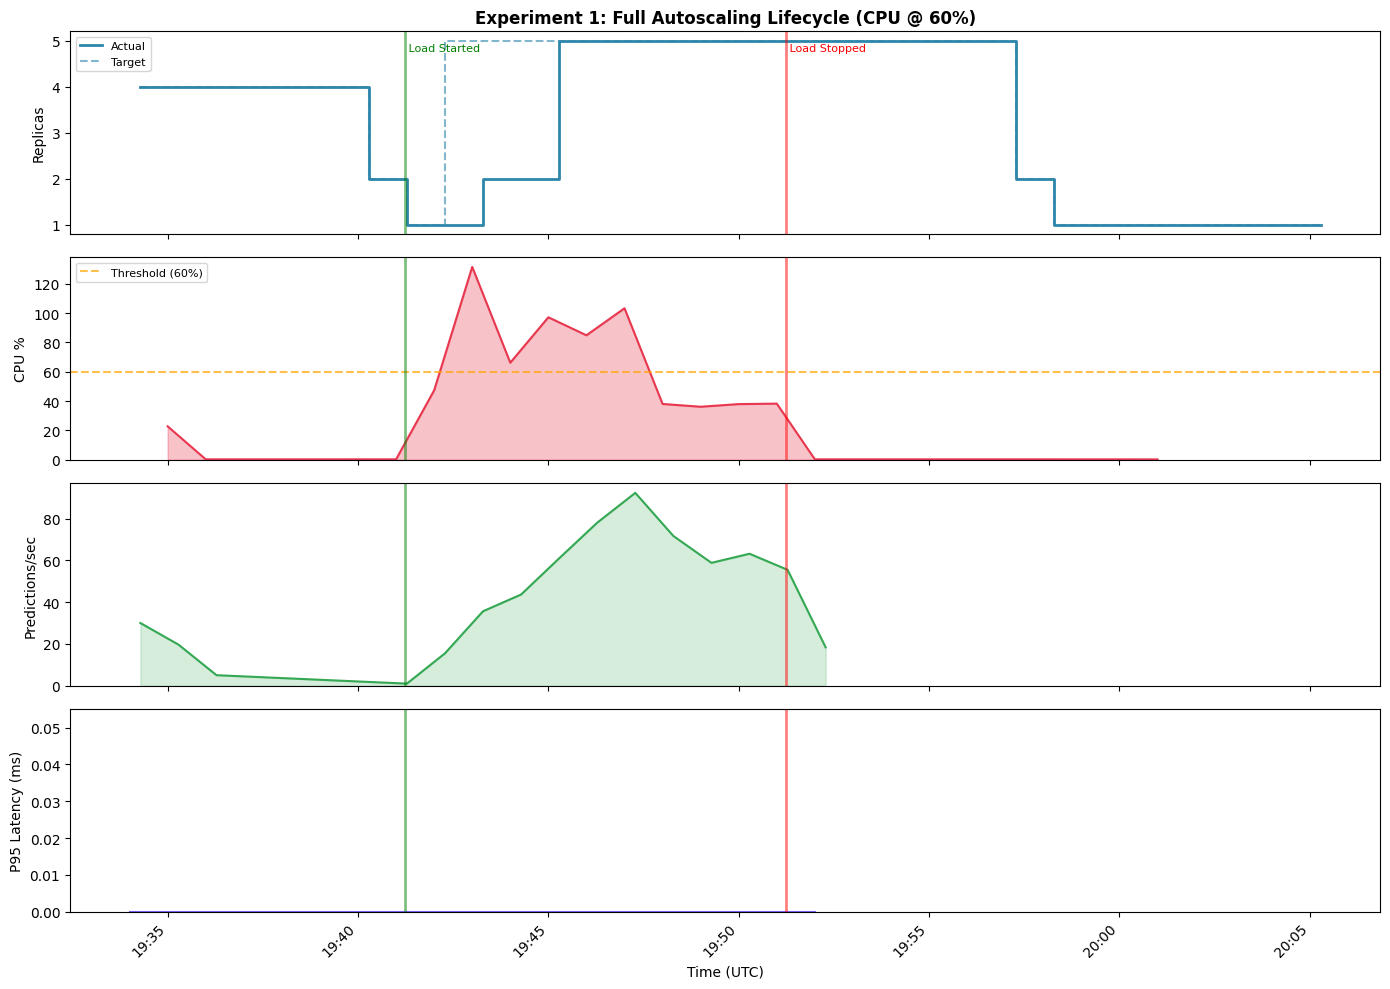


Complete Scaling Timeline:
  19:43:17 — Scale UP to 2 replicas (123s after load start)
  19:45:17 — Scale UP to 5 replicas (243s after load start)
  19:40:17 — Scale DOWN to 2 replicas (-657s after load stop)
  19:41:17 — Scale DOWN to 1 replicas (-597s after load stop)
  19:57:17 — Scale DOWN to 2 replicas (363s after load stop)
  19:58:17 — Scale DOWN to 1 replicas (423s after load stop)


In [39]:
# Wait for final metrics to propagate
print('Waiting 90 seconds for final metrics...')
time.sleep(90)

# Collect the full timeline: pre-load → load → scale-up → post-load → scale-down
scale_down_end = datetime.now(timezone.utc)

print('Collecting full timeline metrics...')
full_metrics = collect_all_metrics(
    ENDPOINT_ID,
    start_time=load_start - timedelta(minutes=5),
    end_time=scale_down_end,
)

plot_autoscaling_dashboard(
    full_metrics,
    title='Experiment 1: Full Autoscaling Lifecycle (CPU @ 60%)',
    events={'Load Started': load_start, 'Load Stopped': load_end},
)

# Updated analysis with scale-down events
full_analysis = analyze_scaling_events(full_metrics, load_start, load_end)
print('\nComplete Scaling Timeline:')
for event in full_analysis.get('events', []):
    if event['type'] == 'scale-up':
        print(f'  {event["time"].strftime("%H:%M:%S")} — Scale UP to {event["replicas"]} '
              f'replicas ({event["lag_from_load_start"]:.0f}s after load start)')
    else:
        print(f'  {event["time"].strftime("%H:%M:%S")} — Scale DOWN to {event["replicas"]} '
              f'replicas ({event["lag_from_load_end"]:.0f}s after load stop)')

---
## Experiment 2: Request-Count Scaling

CPU-based scaling reacts to *compute pressure*. Request-count scaling reacts to *traffic volume*. This is better for:
- **I/O-bound models** where CPU stays low even under load
- **Single-threaded servers** on multi-core machines (CPU appears underutilized)
- **Predictable traffic** where you want to scale based on request rate, not resource utilization

We use `mutateDeployedModel` to switch the scaling metric **without redeploying** — the model stays up and serving throughout.

**Expected duration:** ~12 minutes (10 min load + 2 min metric wait)

### Reconfigure Autoscaling with `mutateDeployedModel`

The high-level Python SDK does not expose `mutateDeployedModel`. We call the REST API directly — the same pattern used for any config change that doesn't require a full redeploy.

In [40]:
def mutate_autoscaling(endpoint_id, deployed_model_id, project_id, region,
                       min_replicas=1, max_replicas=5,
                       cpu_target=None, request_count_target=None):
    """
    Update autoscaling configuration via mutateDeployedModel REST API.
    
    Args:
        cpu_target: CPU utilization target (1-100), or None to remove
        request_count_target: requests/min/replica target, or None to remove
    """
    credentials.refresh(auth_req)
    url = (
        f'https://{region}-aiplatform.googleapis.com/v1/'
        f'projects/{project_id}/locations/{region}/endpoints/{endpoint_id}'
        f':mutateDeployedModel'
    )
    
    # Build autoscaling metric specs
    metric_specs = []
    if cpu_target is not None:
        metric_specs.append({
            'metricName': 'aiplatform.googleapis.com/prediction/online/cpu/utilization',
            'target': cpu_target,
        })
    if request_count_target is not None:
        metric_specs.append({
            'metricName': 'aiplatform.googleapis.com/prediction/online/request_count',
            'target': request_count_target,
        })
    
    body = {
        'deployedModel': {
            'id': deployed_model_id,
            'dedicatedResources': {
                'minReplicaCount': min_replicas,
                'maxReplicaCount': max_replicas,
                'autoscalingMetricSpecs': metric_specs,
            },
        },
        'updateMask': 'dedicatedResources.minReplicaCount,'
                      'dedicatedResources.maxReplicaCount,'
                      'dedicatedResources.autoscalingMetricSpecs',
    }
    
    response = req_lib.post(
        url,
        headers={
            'Authorization': f'Bearer {credentials.token}',
            'Content-Type': 'application/json',
        },
        json=body,
    )
    response.raise_for_status()
    
    config_desc = []
    if cpu_target:     config_desc.append(f'CPU target={cpu_target}%')
    if request_count_target: config_desc.append(f'request_count target={request_count_target}/min/replica')
    print(f'Autoscaling updated: min={min_replicas}, max={max_replicas}, {", ".join(config_desc)}')
    return response.json()

print('mutate_autoscaling() defined')

mutate_autoscaling() defined


### Switch to Request-Count Scaling

In [41]:
# Switch from CPU-based to request-count-based scaling
# Target: 100 requests per minute per replica
# At 20 RPS = 1200 req/min, with target 100/min/replica → should want ~12 replicas
# But max is 5, so it should scale to max=5
mutate_autoscaling(
    ENDPOINT_ID, DEPLOYED_MODEL_ID, PROJECT_ID, REGION,
    min_replicas=1, max_replicas=5,
    request_count_target=100,  # 100 requests/min/replica
)

Autoscaling updated: min=1, max=5, request_count target=100/min/replica


{'name': 'projects/1026793852137/locations/us-central1/endpoints/2082123729042669568/operations/8412347151828385792',
 'metadata': {'@type': 'type.googleapis.com/google.cloud.aiplatform.v1.MutateDeployedModelOperationMetadata',
  'genericMetadata': {'createTime': '2026-04-17T20:06:20.687334Z',
   'updateTime': '2026-04-17T20:06:20.687334Z'}}}

### Run Load with Request-Count Scaling

In [42]:
# Wait a moment for the config change to take effect
print('Waiting 60 seconds for autoscaling config to take effect...')
time.sleep(60)

# Same load pattern as Experiment 1 for fair comparison
rc_load_start, rc_load_end, rc_load_results = await generate_load(
    PREDICT_URL, credentials, auth_req,
    instances=TEST_INSTANCES,
    target_rps=20,
    duration_seconds=600,  # 10 minutes
    max_concurrent=50,
)

Waiting 60 seconds for autoscaling config to take effect...
Generating load: 20 RPS for 600s (12,000 requests)
Progress updates every 60 seconds...
  [  60s] 1,201 sent, 467 completed
  [ 120s] 2,401 sent, 941 completed
  [ 180s] 3,601 sent, 1,433 completed
  [ 240s] 4,801 sent, 2,208 completed
  [ 300s] 6,001 sent, 3,486 completed
  [ 360s] 7,201 sent, 4,860 completed
  [ 420s] 8,401 sent, 6,212 completed
  [ 480s] 9,601 sent, 7,322 completed
  [ 540s] 10,801 sent, 8,577 completed
  Waiting for remaining requests...
Done: 11,506/12,000 succeeded (95.9%), mean latency 2427ms


Waiting 90 seconds for metrics to propagate...
Collected 75 total data points


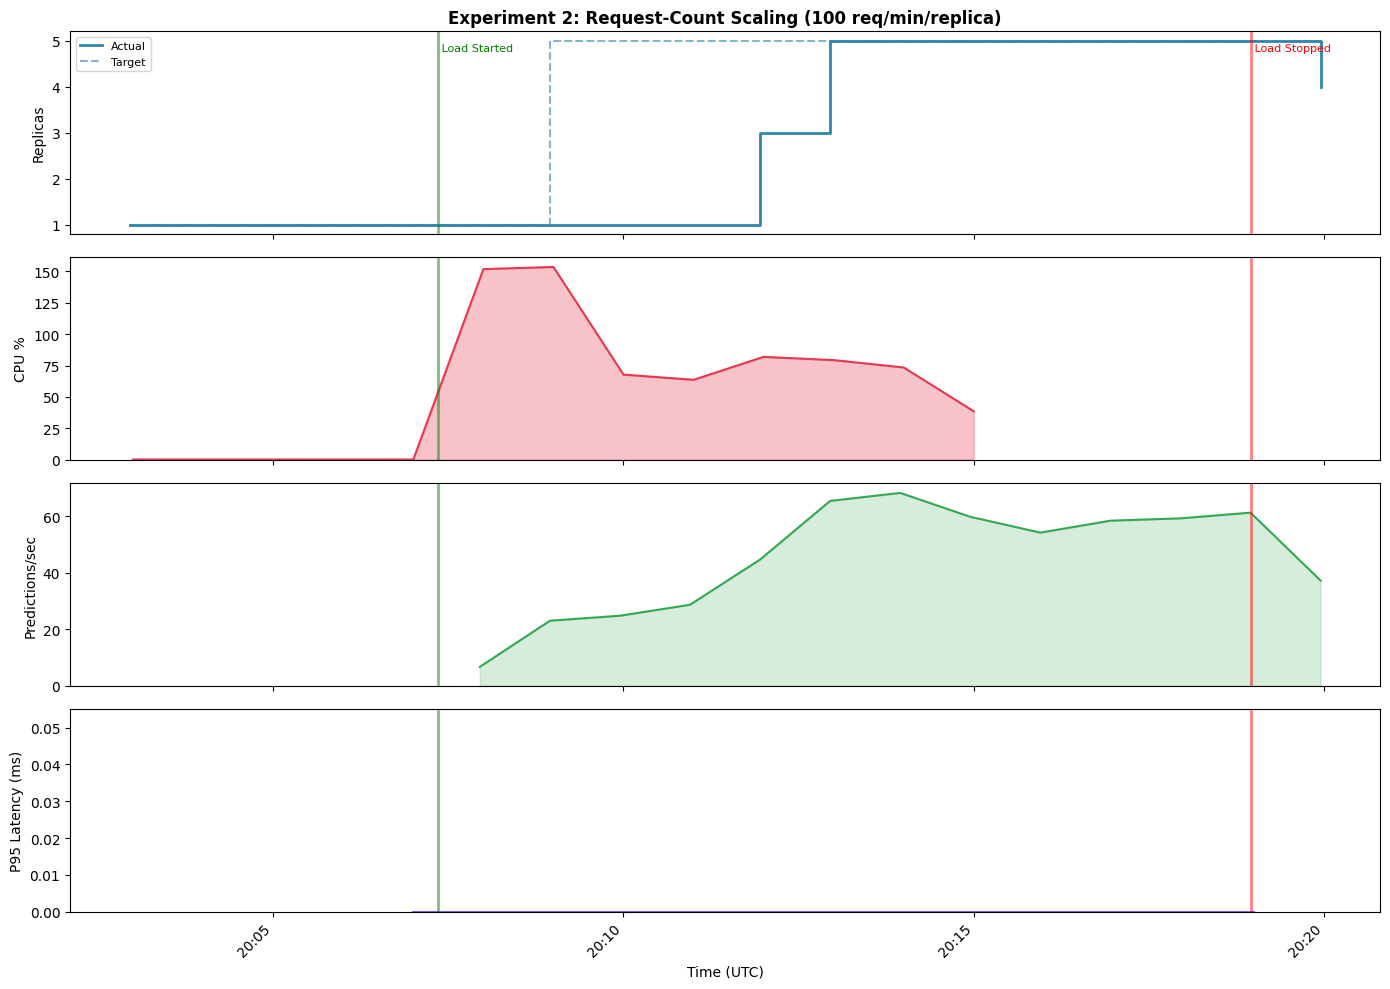

In [43]:
# Wait for metrics
print('Waiting 90 seconds for metrics to propagate...')
time.sleep(90)

# Collect and plot
print('Collecting metrics...')
rc_metrics = collect_all_metrics(
    ENDPOINT_ID,
    start_time=rc_load_start - timedelta(minutes=3),
    end_time=rc_load_end + timedelta(minutes=2),
)

plot_autoscaling_dashboard(
    rc_metrics,
    title='Experiment 2: Request-Count Scaling (100 req/min/replica)',
    events={'Load Started': rc_load_start, 'Load Stopped': rc_load_end},
    cpu_threshold=None,  # CPU threshold not relevant here
)

### Reset to CPU-Based Scaling

In [44]:
# Reset back to default CPU-based scaling for the next experiment
mutate_autoscaling(
    ENDPOINT_ID, DEPLOYED_MODEL_ID, PROJECT_ID, REGION,
    min_replicas=1, max_replicas=5,
    cpu_target=60,
)

# Wait for any scaled-up replicas to scale back down
print('Waiting 2 minutes for replicas to stabilize...')
time.sleep(120)

Autoscaling updated: min=1, max=5, CPU target=60%
Waiting 2 minutes for replicas to stabilize...


---
## Experiment 3: Adjusting the CPU Threshold

The default CPU target is 60%. Lowering it makes the autoscaler more aggressive — scaling up earlier, keeping more headroom. Raising it packs more load per replica before scaling.

We compare 60% (default) vs 30% (aggressive) with the same load pattern.

**Expected duration:** ~7 minutes (5 min load + 2 min metric wait)

In [45]:
# Lower the CPU threshold to 30%
mutate_autoscaling(
    ENDPOINT_ID, DEPLOYED_MODEL_ID, PROJECT_ID, REGION,
    min_replicas=1, max_replicas=5,
    cpu_target=30,  # More aggressive: scale up earlier
)

print('Waiting 60 seconds for config to take effect...')
time.sleep(60)

Autoscaling updated: min=1, max=5, CPU target=30%
Waiting 60 seconds for config to take effect...


In [46]:
# Run moderate load — enough to trigger at 30% but might not at 60%
thresh_load_start, thresh_load_end, thresh_results = await generate_load(
    PREDICT_URL, credentials, auth_req,
    instances=TEST_INSTANCES,
    target_rps=10,  # Lower RPS — moderate load
    duration_seconds=300,  # 5 minutes
    max_concurrent=30,
)

Generating load: 10 RPS for 300s (3,000 requests)
Progress updates every 60 seconds...
  [  60s] 601 sent, 599 completed
  [ 120s] 1,201 sent, 1,199 completed
  [ 180s] 1,801 sent, 1,799 completed
  [ 240s] 2,401 sent, 2,399 completed
  Waiting for remaining requests...
Done: 3,000/3,000 succeeded (100.0%), mean latency 127ms


Waiting 90 seconds for metrics...
Collected 48 total data points


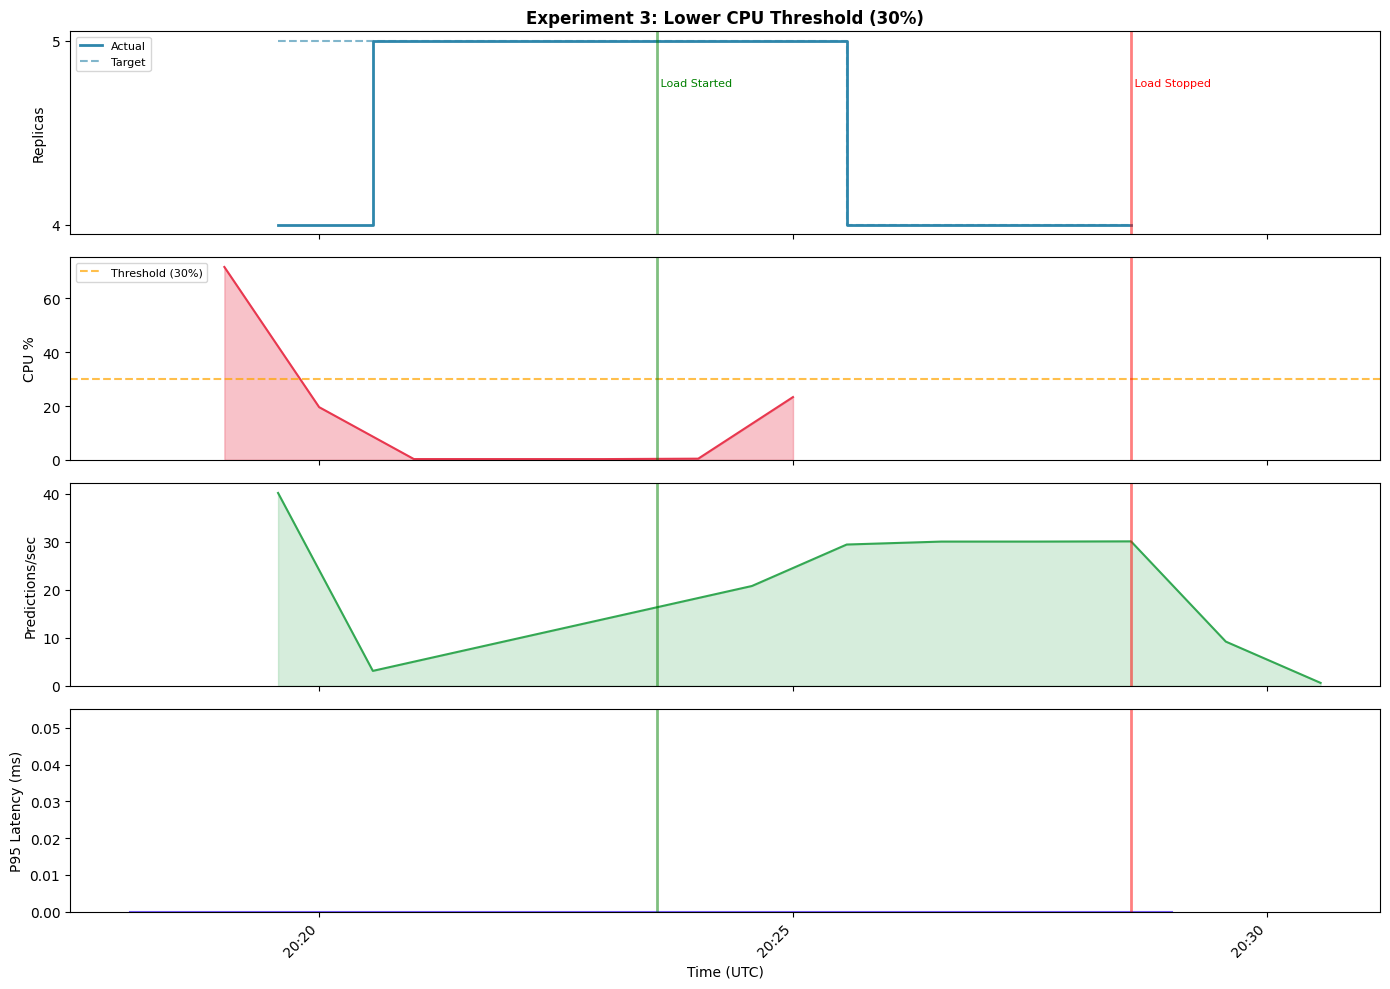

In [47]:
# Wait and collect
print('Waiting 90 seconds for metrics...')
time.sleep(90)

print('Collecting metrics...')
thresh_metrics = collect_all_metrics(
    ENDPOINT_ID,
    start_time=thresh_load_start - timedelta(minutes=3),
    end_time=thresh_load_end + timedelta(minutes=2),
)

plot_autoscaling_dashboard(
    thresh_metrics,
    title='Experiment 3: Lower CPU Threshold (30%)',
    events={'Load Started': thresh_load_start, 'Load Stopped': thresh_load_end},
    cpu_threshold=30,
)

### Comparison Summary

| Configuration | Threshold | Scaling Trigger | Trade-off |
|--------------|:---------:|-----------------|----------|
| Default CPU | 60% | Scales when CPU > 60% | Balanced — good for most workloads |
| Aggressive CPU | 30% | Scales when CPU > 30% | More replicas, lower latency, higher cost |
| Request count | N req/min/replica | Scales on traffic volume | Predictable, ignores compute cost |

The right choice depends on your workload:
- **Latency-sensitive?** Lower the CPU target (30-40%) so scaling triggers before requests queue
- **Cost-sensitive?** Raise the CPU target (70-80%) to pack more work per replica
- **I/O-bound?** Use request-count scaling since CPU won't reflect actual load
- **GPU workload?** The `accelerator/duty_cycle` metric triggers on GPU utilization (same formula, default 60%)

---
## Configuration Reference

### All Autoscaling Parameters

Available via `endpoint.deploy()` or `mutateDeployedModel`:

| Parameter | Default | Description |
|-----------|:-------:|-------------|
| `min_replica_count` | 1 | Minimum always-running replicas |
| `max_replica_count` | 1 | Upper bound (quota charged against this) |
| `autoscaling_target_cpu_utilization` | 60 | CPU target (1-100%) |
| `autoscaling_target_accelerator_duty_cycle` | 60 | GPU target (1-100%, only with GPUs) |
| `autoscaling_target_request_count_per_minute` | — | Requests/min/replica (opt-in) |
| `autoscaling_target_dcgm_fi_dev_gpu_util` | — | DCGM GPU util (Preview) |
| `autoscaling_target_vllm_gpu_cache_usage_perc` | — | vLLM KV cache (Preview) |
| `autoscaling_target_vllm_num_requests_waiting` | — | vLLM queue depth (Preview) |
| `required_replica_count` | — | Succeed once N replicas are ready |

### `mutateDeployedModel` vs Redeploy

| Change | Method | Downtime |
|--------|:------:|:--------:|
| Replica counts (min/max) | `mutateDeployedModel` | None |
| Autoscaling metric/target | `mutateDeployedModel` | None |
| Machine type | Redeploy | Yes |
| Accelerator type/count | Redeploy | Yes |
| Container image | Redeploy | Yes |

### Cost Implications

**Quota is charged against `max_replica_count`, not actual replicas.** If max=5 on `n1-standard-4` (4 vCPUs), that's 20 vCPUs of quota consumed — even if only 1 replica is running.

Billing is based on actual replica hours, but quota reservation means you need sufficient quota headroom for the max, not just the current.

### Gotchas and Best Practices

1. **Single-threaded server on multi-core machine** — If your model server runs 1 worker on an 8-vCPU machine, CPU utilization shows ~12% under full load (1/8 cores). The autoscaler sees low CPU and **never scales up**. Fix: match workers to cores, or use `request_count` metric.

2. **~1 vCPU reserved per replica** — Vertex AI reserves approximately 1 vCPU for system processes. An `n1-standard-2` machine effectively has 1 vCPU for your model.

3. **GPU+CPU interaction** — With GPUs, the autoscaler scales UP when **either** CPU or GPU exceeds its target, but scales DOWN only when **both** are below. A CPU spike from a background process can trigger unwanted scale-up.

4. **5-minute stabilization window** — The autoscaler uses the **highest** target from the last 5 minutes. This is not configurable. Brief load spikes keep replicas up for at least 5 minutes after the spike ends.

5. **Scale-to-zero** — Available via the v1beta1 API with `ScaleToZeroSpec`. Requests during cold start receive **429 errors** (dropped, not queued). Models idle for 30+ days at zero replicas are **automatically undeployed**.

6. **Metric lag** — Cloud Monitoring metrics have 60-120s propagation delay. The autoscaler evaluates metrics internally every 15s (not through Cloud Monitoring), so its decisions are faster than what you see in the charts.

### When to Use Which Configuration

| Scenario | Recommendation |
|----------|---------------|
| General ML model | CPU @ 60% (default) |
| Latency-sensitive API | CPU @ 30-40%, higher `min_replica_count` |
| Cost-sensitive batch-like | CPU @ 70-80% |
| I/O-bound model (calls external APIs) | `request_count` metric |
| GPU inference (non-LLM) | `accelerator/duty_cycle` @ 60% (default with GPU) |
| LLM serving (vLLM) | `vllm_gpu_cache_usage_perc` or `vllm_num_requests_waiting` |
| Event-driven (Pub/Sub trigger) | `pubsub/num_undelivered_messages` |
| Predictable traffic patterns | `min_replica_count` sized for baseline, autoscale for peaks |

For platform-level comparison (Vertex AI vs Cloud Run autoscaling), see the upcoming [Serving Models on Cloud Run](./readme.md) notebook.

---
## Cleanup

Remove all resources created by this notebook.

### Reset Autoscaling Config

In [50]:
# Reset to default config before cleanup
try:
    result = mutate_autoscaling(
        ENDPOINT_ID, DEPLOYED_MODEL_ID, PROJECT_ID, REGION,
        min_replicas=1, max_replicas=1,
        cpu_target=60,
    )

    # Wait for the mutate operation to complete before proceeding to undeploy
    op_name = result.get('name', '')
    if op_name:
        print(f'Waiting for operation to complete...')
        credentials.refresh(auth_req)
        while True:
            resp = req_lib.get(
                f'https://{REGION}-aiplatform.googleapis.com/v1/{op_name}',
                headers={'Authorization': f'Bearer {credentials.token}'},
            )
            if resp.ok and resp.json().get('done'):
                break
            time.sleep(15)
    print('Reset complete: min=1, max=1')
except Exception as e:
    print(f'Reset failed (may already be cleaning up): {e}')

Reset failed (may already be cleaning up): 404 Client Error: Not Found for url: https://us-central1-aiplatform.googleapis.com/v1/projects/statmike-mlops-349915/locations/us-central1/endpoints/2082123729042669568:mutateDeployedModel


### Undeploy All Models and Delete Endpoint

In [51]:
# Undeploy all remaining models
for deployed_model in endpoint.list_models():
    print(f'Undeploying {deployed_model.display_name} ...')
    endpoint.undeploy(deployed_model_id=deployed_model.id)

# Delete the endpoint
print('Deleting endpoint ...')
endpoint.delete(force=True)
print('Endpoint deleted.')

Deleting endpoint ...
Deleting Endpoint : projects/1026793852137/locations/us-central1/endpoints/2082123729042669568
Endpoint deleted. . Resource name: projects/1026793852137/locations/us-central1/endpoints/2082123729042669568
Deleting Endpoint resource: projects/1026793852137/locations/us-central1/endpoints/2082123729042669568
Delete Endpoint backing LRO: projects/1026793852137/locations/us-central1/operations/3968332258590326784
Endpoint resource projects/1026793852137/locations/us-central1/endpoints/2082123729042669568 deleted.
Endpoint deleted.


### Delete Model from Registry

In [52]:
vertex_model.delete()
print('DistilBERT model deleted from registry.')

Deleting Model : projects/1026793852137/locations/us-central1/models/2259468907288985600
Model deleted. . Resource name: projects/1026793852137/locations/us-central1/models/2259468907288985600
Deleting Model resource: projects/1026793852137/locations/us-central1/models/2259468907288985600
Delete Model backing LRO: projects/1026793852137/locations/us-central1/models/2259468907288985600/operations/1299386529419886592
Model resource projects/1026793852137/locations/us-central1/models/2259468907288985600 deleted.
DistilBERT model deleted from registry.


### Remove GCS Artifacts (Optional)

Uncomment to remove the model artifacts and source files from GCS.

In [53]:
# # Remove model artifacts and source files from GCS
# for blob in bucket.list_blobs(prefix=f'{SERIES}/{EXPERIMENT}/'):
#     blob.delete()
# print(f'Removed gs://{GCS_BUCKET}/{SERIES}/{EXPERIMENT}/')